In [47]:

# Analyzed Netflix content dataset using Pandas,Numpy,Matplotlib,
# and seaborn.Performed data cleaning,exploratory data analysis
# and visulation to identify trends in content type,ratings,genres,
# countries and release year


In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

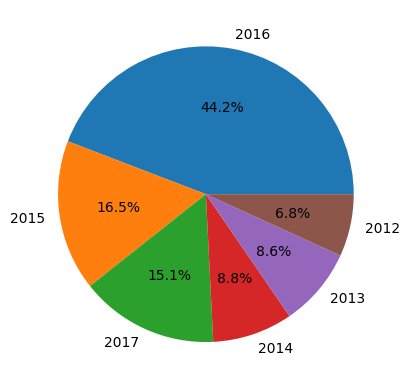

In [69]:
df["release_year"].value_counts().head(6).plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

In [49]:
df =pd.read_csv("netflix.csv")
df

,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80
...,...,...,...,...,...,...,...
995,The BFG,PG,"for action/peril, some scary moments and brief...",60,2016,97.0,80
996,The Secret Life of Pets,PG,for action and some rude humor,60,2016,NaN,81
997,Precious Puppies,TV-G,Suitable for all ages.,35,2003,NaN,82
998,Beary Tales,TV-G,Suitable for all ages.,35,2013,NaN,82


In [50]:
df.describe

<bound method NDFrame.describe of                        title rating  \
0               White Chicks  PG-13   
1        Lucky Number Slevin      R   
2             Grey's Anatomy  TV-14   
3               Prison Break  TV-14   
4      How I Met Your Mother  TV-PG   
..                       ...    ...   
995                  The BFG     PG   
996  The Secret Life of Pets     PG   
997         Precious Puppies   TV-G   
998              Beary Tales   TV-G   
999          Growing Up Wild      G   

                                           ratinglevel  ratingdescription  \
0    crude and sexual humor, language and some drug...                 80   
1    strong violence, sexual content and adult lang...                100   
2    Parents strongly cautioned. May be unsuitable ...                 90   
3    Parents strongly cautioned. May be unsuitable ...                 90   
4    Parental guidance suggested. May not be suitab...                 70   
..                                 

In [51]:
##Basic Exploration##
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(1000, 7)
Index(['title', 'rating', 'ratinglevel', 'ratingdescription', 'release_year',
       'user_rating_score', 'user_rating_size'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   object 
 1   rating             1000 non-null   object 
 2   ratinglevel        941 non-null    object 
 3   ratingdescription  1000 non-null   int64  
 4   release_year       1000 non-null   int64  
 5   user_rating_score  605 non-null    float64
 6   user_rating_size   1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB
None
       ratingdescription  release_year  user_rating_score  user_rating_size
count         1000.00000   1000.000000         605.000000       1000.000000
mean            67.36600   2010.335000          84.094215         80.783000
std     

In [52]:
##Chech missing Values
df.isnull().sum

<bound method DataFrame.sum of      title  rating  ratinglevel  ratingdescription  release_year  \
0    False   False        False              False         False   
1    False   False        False              False         False   
2    False   False        False              False         False   
3    False   False        False              False         False   
4    False   False        False              False         False   
..     ...     ...          ...                ...           ...   
995  False   False        False              False         False   
996  False   False        False              False         False   
997  False   False        False              False         False   
998  False   False        False              False         False   
999  False   False         True              False         False   

     user_rating_score  user_rating_size  
0                False             False  
1                 True             False  
2                False 

<function matplotlib.pyplot.show(close=None, block=None)>

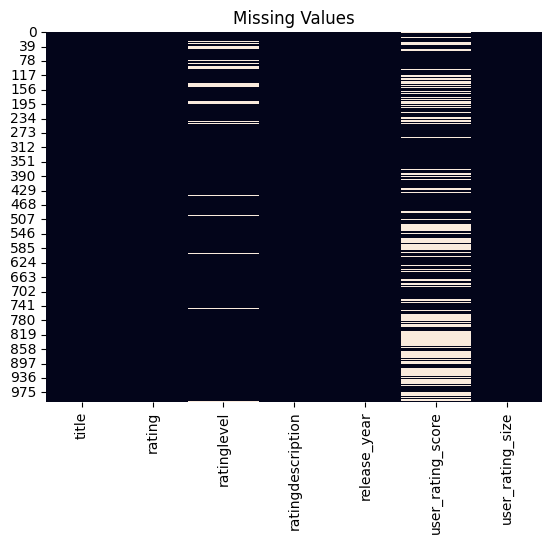

In [53]:
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show

In [54]:
##Top10 Highest Rated Shows
top10=df.sort_values("user_rating_score",ascending=False)
top10[["title","user_rating_score"]].head(10)

,title,user_rating_score
497,13 Reasons Why,99.0
189,13 Reasons Why,99.0
396,13 Reasons Why,99.0
347,13 Reasons Why,99.0
41,13 Reasons Why,99.0
295,13 Reasons Why,99.0
141,13 Reasons Why,99.0
241,13 Reasons Why,99.0
72,Orange Is the New Black,98.0
118,Marvel's Iron Fist,98.0


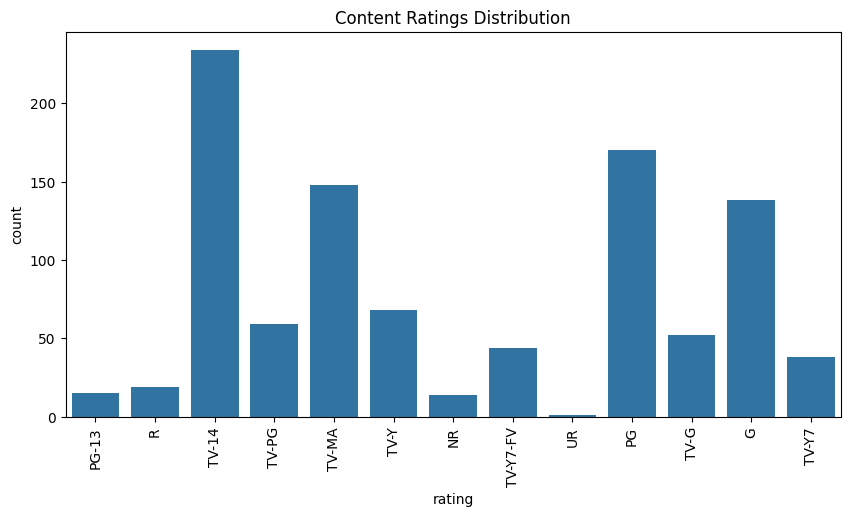

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(x="rating",data=df)
plt.xticks(rotation=90)
plt.title("Content Ratings Distribution")
plt.show()

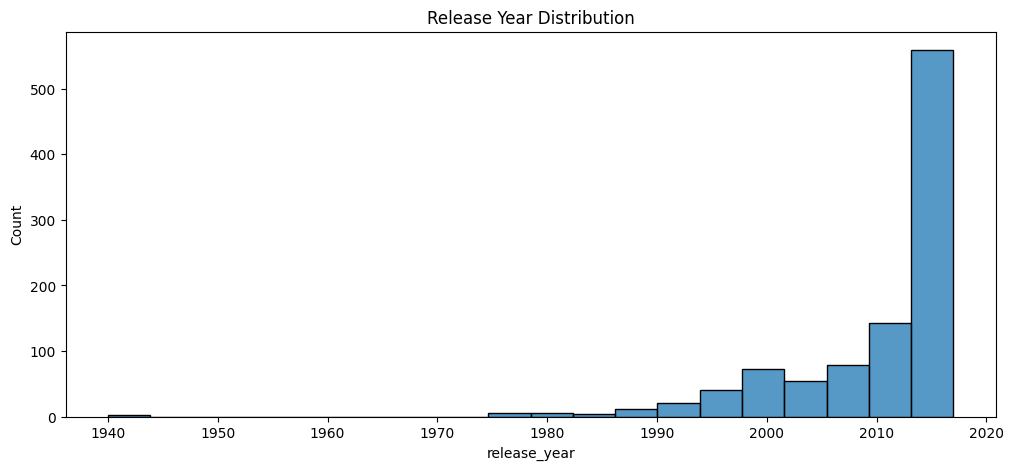

In [56]:
##Release Year Distribution
plt.figure(figsize=(12,5))
sns.histplot(df["release_year"],bins=20)
plt.title("Release Year Distribution")
plt.show()

In [57]:
##Top 10 Release Year
df["release_year"].value_counts().head(10)

release_year
2016    292
2015    109
2017    100
2014     58
2013     57
2012     45
1997     28
1998     26
2008     22
2011     21
Name: count, dtype: int64

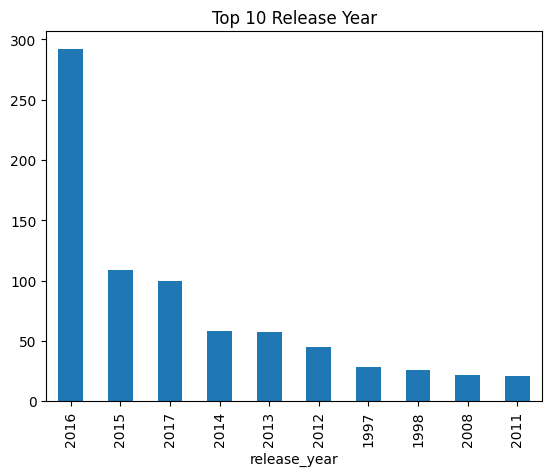

In [58]:
df["release_year"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Release Year")
plt.show()

In [59]:
df["user_rating_score"].mean()
df[df["user_rating_score"]>=95][["title","user_rating_score"]]

,title,user_rating_score
2,Grey's Anatomy,98.0
3,Prison Break,98.0
5,Supernatural,95.0
6,Breaking Bad,97.0
8,The Walking Dead,98.0
...,...,...
860,The Emperor's New Groove,95.0
895,Alice Through the Looking Glass,96.0
901,Homeward Bound: The Incredible Journey,96.0
911,Atlantis: The Lost Empire,96.0


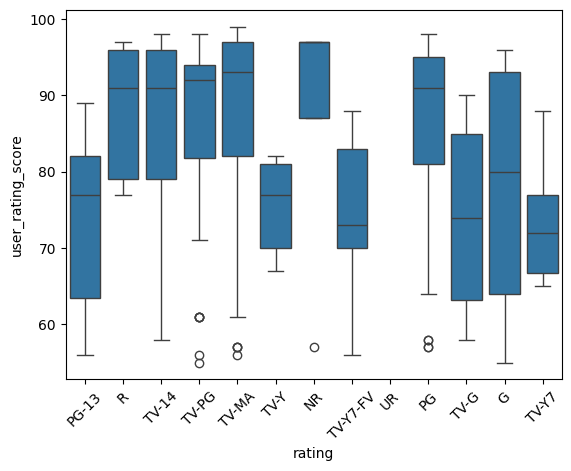

In [60]:
sns.boxplot(x="rating",y="user_rating_score",data=df)
plt.xticks(rotation=45)
plt.show()

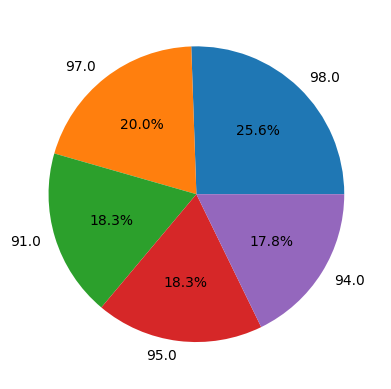

In [61]:
##Common User Rating SCore
df["user_rating_score"].value_counts().head(5).plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

<Axes: ylabel='count'>

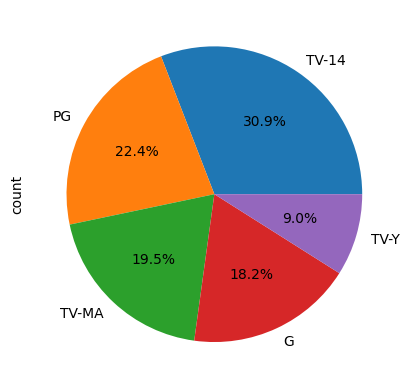

In [62]:
##Most common Rating
df["rating"].value_counts().head(5).plot(kind="pie",autopct="%1.1f%%")

In [63]:
ratings=df["user_rating_score"].dropna().to_numpy()
print(ratings) 

[82. 98. 98. 94. 95. 97. 91. 98. 96. 98. 95. 77. 88. 96. 80. 74. 97. 81.
 57. 95. 98. 94. 98. 84. 83. 82. 94. 99. 89. 92. 97. 98. 98. 62. 96. 94.
 95. 97. 94. 92. 91. 98. 98. 98. 81. 90. 98. 96. 97. 91. 90. 98. 80. 83.
 97. 98. 90. 95. 80. 98. 90. 96. 97. 79. 98. 82. 91. 93. 97. 94. 89. 92.
 93. 61. 78. 97. 66. 75. 91. 63. 94. 98. 97. 62. 91. 92. 98. 90. 95. 80.
 74. 94. 68. 82. 94. 99. 92. 93. 71. 94. 88. 59. 73. 98. 63. 83. 90. 80.
 86. 91. 74. 79. 69. 94. 68. 58. 96. 61. 94. 99. 62. 94. 78. 66. 82. 94.
 91. 79. 55. 62. 91. 73. 58. 80. 90. 80. 81. 86. 63. 74. 69. 94. 68. 69.
 89. 99. 92. 93. 79. 61. 82. 68. 86. 56. 77. 64. 58. 89. 95. 56. 97. 81.
 98. 98. 62. 96. 94. 92. 91. 98. 98. 98. 81. 89. 91. 79. 85. 96. 97. 83.
 91. 81. 92. 62. 80. 93. 79. 90. 95. 90. 98. 77. 99. 84. 61. 94. 82. 86.
 78. 64. 58. 89. 56. 97. 97. 97. 98. 82. 97. 96. 94. 95. 94. 92. 91. 98.
 98. 81. 90. 61. 91. 88. 79. 96. 97. 91. 84. 92. 77. 63. 98. 80. 93. 74.
 94. 95. 97. 98. 91. 69. 94. 99. 61. 98. 85. 98. 89

In [64]:
np.mean(ratings)


np.float64(84.09421487603306)

In [65]:
np.median(ratings)


np.float64(88.0)

In [66]:
np.max(ratings)



np.float64(99.0)

In [67]:
np.min(ratings)

np.float64(55.0)

In [68]:
np.sum(ratings>90)

np.int64(271)